In [2]:
#!/usr/bin/env python3

# Menyesuaikan path agar dapat mengimpor modul dari direktori utama (induk)
# tanpa mengubah struktur direktori proyek
import sys
sys.path.append('..')

# Mengimpor file module untuk melakukan sync semua file
# pada direktori utama (induk)
import module

In [3]:
import os
from pathlib import Path


# Sumber utama dataset CASME
BASE_CASME_DATASET_PATH = os.path.join(Path.home(), "datasets", "secondaries", "casme-clip")

# Memastikan sumber daya dataset CASME tersedia
assert os.path.exists(BASE_CASME_DATASET_PATH), f"Dataset CASME tidak ditemukan di {BASE_CASME_DATASET_PATH}, pastikan dataset sudah diunduh dan ditempatkan dengan benar."

print("Datasource set successfully.")

Datasource set successfully.


In [4]:
import re
import glob
import os

def subject_key(path: str):
    m = re.search(r'[sS](\d+)', path)
    return int(m.group(1)) if m else float('inf')

def frame_key(path: str):
    filename = os.path.basename(path)
    number = os.path.splitext(filename)[0]
    return int(number)

paths = glob.glob(os.path.join(BASE_CASME_DATASET_PATH, "**", "*.jpg"), recursive=True)

sorted_paths = sorted(paths, key=lambda p: (subject_key(p), frame_key(p)))

print(sorted_paths)

['/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/7.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/8.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/9.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/10.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/11.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/12.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/13.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/14.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/15.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/16.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/17.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/18.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/19.jpg', '/home/inadio/datasets/secondaries/casme-clip/spNO.1/a/color/20.jpg', '/home/inadio/datasets

W0000 00:00:1772886761.398160    8972 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1772886761.406452    8980 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772886761.436547    8989 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


835 31 4


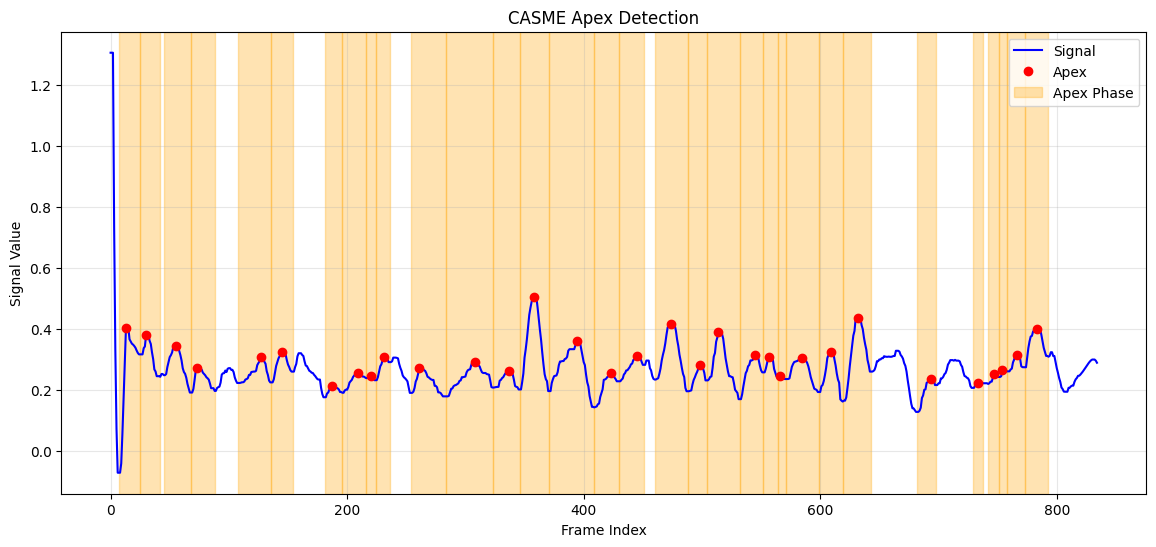

In [7]:
from src.apex.modules.v3 import ApexPhaseSpotter, ApexPhaseVisualizer, ApexSmoother

spotter = ApexPhaseSpotter()

visualizer = ApexPhaseVisualizer()

apexes, phases = spotter.process_images(sorted_paths)

visualizer.plot_phases(signal=spotter.magnitudes, 
                       phases=phases, 
                       apex_indices=apexes, 
                       title="CASME Apex Detection")